In [2]:
import torch
from datasets import load_dataset
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
# KITAB-Bench is hosted on HuggingFace by MBZUAI
# The "OCR" config gives us the OCR-specific subset
print("Loading KITAB-Bench OCR subset...")
dataset = load_dataset("ahmedheakl/arocrbench_synthesizear", split="train")

print(f"Dataset loaded.")
print(f"Number of samples: {len(dataset)}")
print(f"First sample keys: {list(dataset[0].keys())}")

Loading KITAB-Bench OCR subset...
Dataset loaded.
Number of samples: 500
First sample keys: ['image', 'text', 'source']


Source: synthesizear
Ground truth text (55 chars):
وَإِذا ما سَأَلَتْنِي عَن مَعْنَى لَفَظَهُ "عرب" عِنْدَ

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (639, 114)


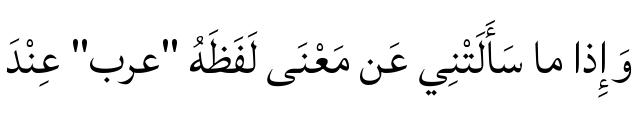

In [4]:
sample = dataset[0]
print(f"Source: {sample['source']}")
print(f"Ground truth text ({len(sample['text'])} chars):")
print(sample['text'])
print()

# Display the image inline
print(f"Image type: {type(sample['image'])}")
print(f"Image size: {sample['image'].size}")
sample['image']

In [5]:
for idx in [50, 200, 450]:
    s = dataset[idx]
    print(f"=== Sample {idx} ===")
    print(f"Source: {s['source']}")
    print(f"Text ({len(s['text'])} chars): {s['text'][:100]}{'...' if len(s['text']) > 100 else ''}")
    print(f"Image size: {s['image'].size}")
    print()

=== Sample 50 ===
Source: synthesizear
Text (50 chars): فِي بِعَضِّ المواسم، أَو كانَ بَقايا نهر، أَثَّرَت
Image size: (952, 136)

=== Sample 200 ===
Source: synthesizear
Text (59 chars): بِالناسِ ثُمَّ التكون الجُسْمانِيّ ومظهره. وَمِن هُنا نَجِد
Image size: (1463, 223)

=== Sample 450 ===
Source: synthesizear
Text (73 chars): الكَيْفِيَّةِ الَّتِي تَنْتَقِل بِها هٰذِهِ الإِشْعاعات عَبْرَ الأَوْساطُ
Image size: (1061, 125)



In [6]:
# Load Surya (same as previous notebooks)
from surya.foundation import FoundationPredictor
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor

print("Loading Surya...")
foundation_predictor = FoundationPredictor()
recognition_predictor = RecognitionPredictor(foundation_predictor)
detection_predictor = DetectionPredictor()
print("Surya loaded.")

Loading Surya...
Surya loaded.


In [7]:
import time

# Process first 5 samples
N_TEST = 5
results = []

print(f"Running Surya on {N_TEST} samples...\n")

for i in range(N_TEST):
    sample = dataset[i]
    image = sample['image']
    ground_truth = sample['text']
    
    start = time.time()
    predictions = recognition_predictor([image], det_predictor=detection_predictor)
    elapsed = time.time() - start
    
    # Surya returns a list of detected text lines per image
    # For single-line samples, we concatenate
    ocr_lines = [line.text for line in predictions[0].text_lines]
    ocr_output = " ".join(ocr_lines)
    
    results.append({
        'index': i,
        'ground_truth': ground_truth,
        'ocr_output': ocr_output,
        'time_seconds': elapsed,
        'gt_length': len(ground_truth),
        'ocr_length': len(ocr_output),
    })
    
    print(f"Sample {i}: {elapsed:.2f}s, GT={len(ground_truth)} chars, OCR={len(ocr_output)} chars")
    print(f"  GT:  {ground_truth}")
    print(f"  OCR: {ocr_output}")
    print()

total_time = sum(r['time_seconds'] for r in results)
print(f"Total: {total_time:.2f}s for {N_TEST} samples ({total_time/N_TEST:.2f}s/sample average)")

Running Surya on 5 samples...



Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:04<00:00,  4.57s/it]


Sample 0: 8.07s, GT=55 chars, OCR=56 chars
  GT:  وَإِذا ما سَأَلَتْنِي عَن مَعْنَى لَفَظَهُ "عرب" عِنْدَ
  OCR: وَ إِذا ما سَأَلَتْنِي عَن مَعْنَى لَفَظَهُ "عرب" عِنْدَ



Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:04<00:00,  4.12s/it]


Sample 1: 4.56s, GT=68 chars, OCR=69 chars
  GT:  أَمّا فَهُم النُصُوصِ وَاِسْتِنْباط مَعانِيها بِوَجْهٍ صَحِيحٌ دقيق،
  OCR: أَمَّا فَهُم النُّصُوصِ وَاسْتِنْباط مَعانِيها بِوَجْهٍ صَحِيحٌ دقيق،



...

Sample 2: 3.64s, GT=56 chars, OCR=56 chars
  GT:  تُثِير فِيها الاسود، وَهُوَ ما يَتَعارَض مَعَ اِكْتِشافِ
  OCR: تُثِير فِيها الاسود، وَهُوَ ما يَتَعارَض مَعَ اِكْتِشافِ



Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:04<00:00,  4.45s/it]


Sample 3: 4.88s, GT=80 chars, OCR=80 chars
  GT:  الجماعي، وَكادَت تَصِل إِلَى المَرْحَلَةِ الاِشْتِراكِيَّة لِسَيْطَرَةِ أَكْبَرَ
  OCR: الجماعي، وَكادَت تَصِل إِلَى المَرْحَلَةِ الاِشْتِراكِيَّة لِسَيْطَرَةِ أَكْبَرَ



Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:03<00:00,  3.62s/it]

Sample 4: 4.11s, GT=62 chars, OCR=62 chars
  GT:  مَعَهُ مَنْدِيلا فِيهِ جردقتان وَقَطَعَ لَحْم سَكْباج مُبَرَّد
  OCR: مَعَهُ مَنْدِيلا فِيهِ جردقتان وَقَطَعَ لَحْم سَكْباج مُبَرَّد

Total: 25.25s for 5 samples (5.05s/sample average)


In [8]:
import jiwer

print("=== CER per sample ===\n")
cer_per_sample = []

for r in results:
    gt = r['ground_truth']
    ocr = r['ocr_output']
    cer = jiwer.cer(gt, ocr)
    cer_per_sample.append(cer)
    print(f"Sample {r['index']}: CER = {cer*100:.2f}%")
    if cer > 0:
        print(f"  GT:  {gt}")
        print(f"  OCR: {ocr}")
    print()

avg_cer = sum(cer_per_sample) / len(cer_per_sample)
print(f"Average CER across {len(cer_per_sample)} samples: {avg_cer*100:.2f}%")

=== CER per sample ===

Sample 0: CER = 1.82%
  GT:  وَإِذا ما سَأَلَتْنِي عَن مَعْنَى لَفَظَهُ "عرب" عِنْدَ
  OCR: وَ إِذا ما سَأَلَتْنِي عَن مَعْنَى لَفَظَهُ "عرب" عِنْدَ

Sample 1: CER = 4.41%
  GT:  أَمّا فَهُم النُصُوصِ وَاِسْتِنْباط مَعانِيها بِوَجْهٍ صَحِيحٌ دقيق،
  OCR: أَمَّا فَهُم النُّصُوصِ وَاسْتِنْباط مَعانِيها بِوَجْهٍ صَحِيحٌ دقيق،

Sample 2: CER = 0.00%

Sample 3: CER = 0.00%

Sample 4: CER = 0.00%

Average CER across 5 samples: 1.25%


In [9]:
# Run on a larger subset for a statistically meaningful CER number
N_SAMPLES = 50
all_results = []

print(f"Running Surya on {N_SAMPLES} samples...\n")
start_total = time.time()

for i in range(N_SAMPLES):
    sample = dataset[i]
    image = sample['image']
    ground_truth = sample['text']
    
    start = time.time()
    predictions = recognition_predictor([image], det_predictor=detection_predictor)
    elapsed = time.time() - start
    
    ocr_lines = [line.text for line in predictions[0].text_lines]
    ocr_output = " ".join(ocr_lines)
    
    cer = jiwer.cer(ground_truth, ocr_output)
    
    all_results.append({
        'index': i,
        'ground_truth': ground_truth,
        'ocr_output': ocr_output,
        'time_seconds': elapsed,
        'cer': cer,
        'gt_length': len(ground_truth),
    })
    
    # Print progress every 10 samples (don't flood the notebook)
    if (i + 1) % 10 == 0:
        elapsed_so_far = time.time() - start_total
        running_avg_cer = sum(r['cer'] for r in all_results) / len(all_results)
        print(f"[{i+1}/{N_SAMPLES}] avg CER so far: {running_avg_cer*100:.2f}%, elapsed: {elapsed_so_far:.1f}s")

total_time = time.time() - start_total
print(f"\nDone. Total time: {total_time:.1f}s ({total_time/N_SAMPLES:.2f}s/sample)")

Running Surya on 50 samples...



Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:04<00:00,  4.19s/it]


[10/50] avg CER so far: 2.14%, elapsed: 42.8s


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:03<00:00,  3.96s/it]


[20/50] avg CER so far: 11.73%, elapsed: 80.8s


...

[30/50] avg CER so far: 9.02%, elapsed: 123.9s


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:02<00:00,  2.22s/it]


[40/50] avg CER so far: 12.23%, elapsed: 163.7s


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:02<00:00,  2.55s/it]

[50/50] avg CER so far: 16.01%, elapsed: 209.3s

Done. Total time: 209.3s (4.19s/sample)


In [10]:
import statistics

# Extract CER values
cer_values = [r['cer'] for r in all_results]

# Summary stats
print("=== CER distribution across 50 samples ===\n")
print(f"Mean:     {statistics.mean(cer_values)*100:.2f}%")
print(f"Median:   {statistics.median(cer_values)*100:.2f}%")
print(f"Stdev:    {statistics.stdev(cer_values)*100:.2f}%")
print(f"Min:      {min(cer_values)*100:.2f}%")
print(f"Max:      {max(cer_values)*100:.2f}%")
print()

# Distribution buckets
buckets = {
    "Perfect (0%)":      sum(1 for c in cer_values if c == 0),
    "Excellent (0-2%)":  sum(1 for c in cer_values if 0 < c <= 0.02),
    "Good (2-5%)":       sum(1 for c in cer_values if 0.02 < c <= 0.05),
    "Acceptable (5-10%)": sum(1 for c in cer_values if 0.05 < c <= 0.10),
    "Poor (10-30%)":     sum(1 for c in cer_values if 0.10 < c <= 0.30),
    "Failed (>30%)":     sum(1 for c in cer_values if c > 0.30),
}
print("Distribution:")
for label, count in buckets.items():
    bar = "█" * count
    print(f"  {label:<22} {count:>3}  {bar}")
print()

# Show the worst 5 samples
print("=== Worst 5 samples by CER ===\n")
worst = sorted(all_results, key=lambda r: r['cer'], reverse=True)[:5]
for r in worst:
    print(f"Sample {r['index']}: CER = {r['cer']*100:.2f}% (GT length: {r['gt_length']})")
    print(f"  GT:  {r['ground_truth']}")
    print(f"  OCR: {r['ocr_output']}")
    print()

=== CER distribution across 50 samples ===

Mean:     16.01%
Median:   3.92%
Stdev:    44.00%
Min:      0.00%
Max:      288.24%

Distribution:
  Perfect (0%)            14  ██████████████
  Excellent (0-2%)         5  █████
  Good (2-5%)             12  ████████████
  Acceptable (5-10%)       8  ████████
  Poor (10-30%)            6  ██████
  Failed (>30%)            5  █████

=== Worst 5 samples by CER ===

Sample 43: CER = 288.24% (GT length: 68)
  GT:  طَبَّقَت عَلَى الأَشْجارِ خِلالَ فَتْرَةٍ الدراسه، حَيْثُ اِعْتَمَدَ
  OCR: كالمراه المقالت عالم الله المجادة عالم الا فالمتالات المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية المالية ا

Sample 34: CER = 100.00% (GT length: 9)
  GT:  الأُخْرَى
  OCR: С

Sample 12: CER = 75.00% (GT length: 8)
  GT:  العربيه،
  OCR: الع سه 88

Sample 14: CER = 60.24% (GT length: 83)
  GT:  تَتَحَمَّل المَسْؤُولِيَّةِ المُتَعَلِّقَةِ بِخُطَّة 

In [11]:
import time

# Re-run Surya on the same 50 samples, capturing confidence this time
N_SAMPLES = 50
calibration_results = []

print(f"Re-running Surya on {N_SAMPLES} samples to capture confidence scores...\n")
start_total = time.time()

for i in range(N_SAMPLES):
    sample = dataset[i]
    image = sample['image']
    ground_truth = sample['text']
    
    predictions = recognition_predictor([image], det_predictor=detection_predictor)
    
    # Collect per-line OCR text and confidence
    text_lines = predictions[0].text_lines
    ocr_lines = [line.text for line in text_lines]
    line_confidences = [line.confidence for line in text_lines]
    
    ocr_output = " ".join(ocr_lines)
    
    # Aggregate to per-sample confidence
    # Two natural choices: mean confidence, or min confidence
    # We capture both; min is more conservative for safety routing
    if line_confidences:
        mean_conf = sum(line_confidences) / len(line_confidences)
        min_conf = min(line_confidences)
    else:
        mean_conf = 0.0
        min_conf = 0.0
    
    cer = jiwer.cer(ground_truth, ocr_output)
    
    calibration_results.append({
        'index': i,
        'ground_truth': ground_truth,
        'ocr_output': ocr_output,
        'cer': cer,
        'n_lines': len(text_lines),
        'line_confidences': line_confidences,
        'mean_confidence': mean_conf,
        'min_confidence': min_conf,
    })
    
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start_total
        print(f"[{i+1}/{N_SAMPLES}] elapsed: {elapsed:.1f}s")

total = time.time() - start_total
print(f"\nDone. {total:.1f}s")

Re-running Surya on 50 samples to capture confidence scores...



Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:06<00:00,  6.04s/it]


[10/50] elapsed: 45.7s


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:03<00:00,  3.93s/it]


[20/50] elapsed: 89.1s


...

[30/50] elapsed: 131.0s


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:02<00:00,  2.32s/it]


[40/50] elapsed: 168.7s


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:02<00:00,  2.44s/it]

[50/50] elapsed: 213.6s

Done. 213.6s


In [12]:
# Quick look at the data we collected
print("Sample-level confidence and CER:")
print(f"{'Idx':<5}{'CER':<10}{'Mean conf':<12}{'Min conf':<12}{'N lines':<10}")
print("-" * 50)
for r in calibration_results:
    print(f"{r['index']:<5}{r['cer']*100:>7.2f}%  {r['mean_confidence']:<12.4f}{r['min_confidence']:<12.4f}{r['n_lines']:<10}")

Sample-level confidence and CER:
Idx  CER       Mean conf   Min conf    N lines   
--------------------------------------------------
0       1.82%  0.9726      0.9726      1         
1       4.41%  0.9674      0.9674      1         
2       0.00%  0.9953      0.9953      1         
3       0.00%  0.9992      0.9992      1         
4       0.00%  0.9974      0.9974      1         
5       1.92%  0.9959      0.9959      1         
6       8.75%  0.9241      0.9241      1         
7       1.79%  0.9968      0.9968      1         
8       0.00%  0.9921      0.9921      1         
9       2.67%  0.9797      0.9797      1         
10     21.05%  0.4553      0.4553      1         
11      6.15%  0.9983      0.9983      1         
12     75.00%  0.7383      0.4755      3         
13     11.84%  0.9972      0.9972      1         
14     60.24%  0.7231      0.1715      3         
15     28.57%  0.9097      0.9097      1         
16      1.79%  0.9962      0.9962      1         
17      4.17%  0

In [13]:
import statistics

# Extract paired data
confidences = [r['min_confidence'] for r in calibration_results]
cers = [r['cer'] for r in calibration_results]

# Pearson correlation (manual implementation, no scipy needed)
n = len(confidences)
mean_c = sum(confidences) / n
mean_e = sum(cers) / n
num = sum((c - mean_c) * (e - mean_e) for c, e in zip(confidences, cers))
den_c = sum((c - mean_c) ** 2 for c in confidences) ** 0.5
den_e = sum((e - mean_e) ** 2 for e in cers) ** 0.5
pearson = num / (den_c * den_e)

print(f"Pearson correlation (min_confidence vs CER): {pearson:.4f}")
print()

# Threshold analysis: what does "confidence > 0.9" predict?
threshold = 0.9
above = [r for r in calibration_results if r['min_confidence'] >= threshold]
below = [r for r in calibration_results if r['min_confidence'] < threshold]

# Define "acceptable" as CER < 10% — within the case study's triage tolerance
def cer_bucket(cer):
    return "acceptable" if cer < 0.10 else "unacceptable"

print(f"=== Confidence threshold = {threshold} ===\n")
print(f"Above threshold (system would trust): {len(above)} samples")
above_buckets = {"acceptable": 0, "unacceptable": 0}
for r in above:
    above_buckets[cer_bucket(r['cer'])] += 1
print(f"  Acceptable CER (good outputs we correctly trusted): {above_buckets['acceptable']}")
print(f"  Unacceptable CER (BAD outputs we wrongly trusted):  {above_buckets['unacceptable']}")
print()
print(f"Below threshold (system would flag for interpreter): {len(below)} samples")
below_buckets = {"acceptable": 0, "unacceptable": 0}
for r in below:
    below_buckets[cer_bucket(r['cer'])] += 1
print(f"  Acceptable CER (good outputs we unnecessarily flagged): {below_buckets['acceptable']}")
print(f"  Unacceptable CER (bad outputs we correctly flagged):    {below_buckets['unacceptable']}")
print()

# Precision and recall for the "flag bad outputs" task
true_positives = below_buckets['unacceptable']  # correctly flagged bad outputs
false_positives = below_buckets['acceptable']   # incorrectly flagged good outputs
false_negatives = above_buckets['unacceptable']  # missed bad outputs (the dangerous case)
true_negatives = above_buckets['acceptable']     # correctly trusted good outputs

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

print(f"At threshold {threshold}:")
print(f"  Recall on bad outputs (caught {true_positives}/{true_positives + false_negatives}): {recall:.2%}")
print(f"  Precision on flags ({true_positives}/{true_positives + false_positives} flagged were bad): {precision:.2%}")

Pearson correlation (min_confidence vs CER): -0.7025

=== Confidence threshold = 0.9 ===

Above threshold (system would trust): 42 samples
  Acceptable CER (good outputs we correctly trusted): 38
  Unacceptable CER (BAD outputs we wrongly trusted):  4

Below threshold (system would flag for interpreter): 8 samples
  Acceptable CER (good outputs we unnecessarily flagged): 1
  Unacceptable CER (bad outputs we correctly flagged):    7

At threshold 0.9:
  Recall on bad outputs (caught 7/11): 63.64%
  Precision on flags (7/8 flagged were bad): 87.50%


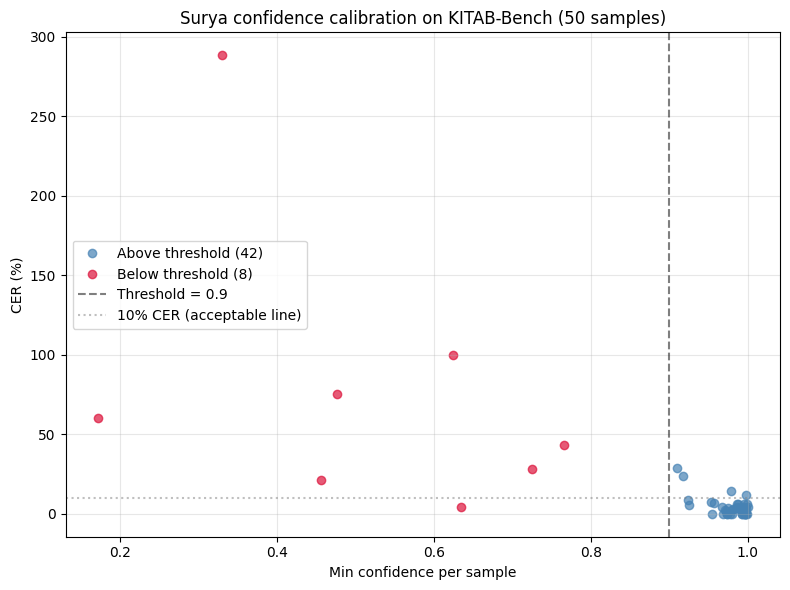

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Color points by whether they were flagged
above_x = [r['min_confidence'] for r in above]
above_y = [r['cer']*100 for r in above]
below_x = [r['min_confidence'] for r in below]
below_y = [r['cer']*100 for r in below]

ax.scatter(above_x, above_y, label=f'Above threshold ({len(above)})', color='steelblue', alpha=0.7)
ax.scatter(below_x, below_y, label=f'Below threshold ({len(below)})', color='crimson', alpha=0.7)
ax.axvline(threshold, color='black', linestyle='--', alpha=0.5, label=f'Threshold = {threshold}')
ax.axhline(10, color='gray', linestyle=':', alpha=0.5, label='10% CER (acceptable line)')

ax.set_xlabel('Min confidence per sample')
ax.set_ylabel('CER (%)')
ax.set_title('Surya confidence calibration on KITAB-Bench (50 samples)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Sweep thresholds to find the right tradeoff
print(f"{'Threshold':<12}{'Flagged':<10}{'Recall':<12}{'Precision':<12}{'Caught/Total bad':<20}")
print("-" * 70)

# Define "bad" as CER >= 10%
n_bad_total = sum(1 for r in calibration_results if r['cer'] >= 0.10)

for thresh in [0.62, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99]:
    flagged = [r for r in calibration_results if r['min_confidence'] < thresh]
    caught_bad = sum(1 for r in flagged if r['cer'] >= 0.10)
    flagged_good = sum(1 for r in flagged if r['cer'] < 0.10)
    
    recall = caught_bad / n_bad_total if n_bad_total > 0 else 0
    precision = caught_bad / len(flagged) if flagged else 0
    
    print(f"{thresh:<12}{len(flagged):<10}{recall:<12.2%}{precision:<12.2%}{caught_bad}/{n_bad_total}")

Threshold   Flagged   Recall      Precision   Caught/Total bad    
----------------------------------------------------------------------
0.62        4         36.36%      100.00%     4/11
0.85        8         63.64%      87.50%      7/11
0.9         8         63.64%      87.50%      7/11
0.92        10        81.82%      90.00%      9/11
0.95        12        81.82%      75.00%      9/11
0.97        17        81.82%      52.94%      9/11
0.99        32        90.91%      31.25%      10/11


In [16]:
import json, jiwer
from datasets import load_dataset

dataset = load_dataset("ahmedheakl/arocrbench_synthesizear", split="train")

surya_outputs = []
for i in range(50):
    sample = dataset[i]
    gt = sample["text"]
    predictions = recognition_predictor([sample["image"]], det_predictor=detection_predictor)
    lines = [l.text for l in predictions[0].text_lines]
    confs = [l.confidence for l in predictions[0].text_lines]
    ocr_text = " ".join(lines)
    surya_outputs.append({
        "index": i,
        "gt": gt,
        "surya_text": ocr_text,
        "surya_min_conf": min(confs) if confs else 0.0,
        "surya_cer": jiwer.cer(gt, ocr_text),
    })
    if (i+1) % 10 == 0: print(f"{i+1}/50")

with open("surya_50_outputs.json", "w", encoding="utf-8") as f:
    json.dump(surya_outputs, f, ensure_ascii=False, indent=2)
print("Saved surya_50_outputs.json")

Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:04<00:00,  4.50s/it]


10/50


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:04<00:00,  4.01s/it]


20/50


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:03<00:00,  3.84s/it]


30/50


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:02<00:00,  2.38s/it]


40/50


Recognizing Text: 100%|█████████████████████████████████| 1/1 [00:02<00:00,  2.47s/it]

50/50
Saved surya_50_outputs.json
